In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd

import openpyxl

import sys
import os
import runpy

import requests
from io import StringIO
import json

import json
import glob
from pathlib import Path

import pickle

In [2]:
target_excels_fpath = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\3. treatment\_target_excels"
clean_fpath = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\clean\treatment\eu_flows"

In [3]:
from processing_functions import parse_and_explode_locations, build_teryt_lookup_optimized, assign_geo_ids, disaggregate_powiat_funding, distribute_funding_over_time

In [4]:
df_201420 = pd.read_excel(target_excels_fpath + r"\Lista_projektow_FE_2014_2020_04012026.xlsx", header=2)
df_201420.columns = df_201420.columns.str.replace(r'/ .*$', '', regex=True)
# df_201420.columns.tolist()

In [5]:
# (w\xa0zł, dla projektów EWT w euro)',

rename_dict = {    
                "Numer umowy/decyzji" : "ID",
                "Numer umowy/aneksu/decyzji" : "ID",
                "Tytuł projektu" : "project_title",
                "Program Operacyjny <Nazwa>" : 'program',
                "Oś priorytetowa <Kod>" : 'priority_code',
                "Działanie <Kod>" : "action_code",
                "Poddziałanie <Kod>" : "subaction_code",
                "Województwo" : "voviodeship",
                "Powiat" : "powiat",
                "Gmina" : "gmina",
                "Wartość ogółem" : "total_value_PLN",
                "Wydatki kwalifikowalne" : "eligible_expenses_PLN",
                "Dofinansowanie" : "subsidy_PLN",
                "Dofinansowanie UE" : "EU_subsidy_PLN",
                "Nazwa beneficjenta" : "beneficiary",
                "NIP beneficjenta" : "beneficiary_ID",
                "Kod pocztowy" : "beneficiary_postal_code",
                "Miejscowość" : "beneficiary_city",
                "Województwo.1" : "beneficiary_voviodeship",
                "Powiat.1" : "beneficiary_powiat",
                "Temat priorytetu" : "priority_theme",
                "Forma prawna" : "beneficiary_status",
                "Obszar realizacji" : "terriority_type",
                "Projekt zakończony (Wniosek o płatność końcową)" : "project_completed",
                "Data podpisania Umowy/Aneksu" : "signing_date",
                "Data utworzenia w KSI SIMIK 07-13 Umowy/Aneksu" : "creation_date_KSI_SIMIK_07_12",
                "Data rozpoczęcia realizacji" : "start_date",
                "Data zakończenia realizacji" : "end_date",
                
                'Skrócony opis [do 2000 znaków] ' : 'short_desc',
                'Fundusz' : 'eu_fund',
                'Program' : 'program',
                'Priorytet' : 'priority',
                'Działanie' : 'action',
                'Poddziałanie' : 'subaction',
                'Wartość projektu (w\xa0zł, dla projektów EWT w euro)' : 'total_value_PLN',
                'Wydatki kwalifikowalne (w\xa0zł, dla projektów EWT w euro)' : "eligible_expenses_PLN",
                'Wartość unijnego dofinansowania (w\xa0zł, dla projektów EWT w euro)' : "EU_subsidy_PLN",
                'Poziom unijnego dofinansowania w procentach (w\xa0%)' : 'EU_subsidy_PLN_perc',
                'Forma finansowania' : 'funding_type',
                'Miejsce\xa0realizacji\xa0projektu/\xa0Project\xa0location' : 'project_place',
                'Typ obszaru, na którym realizowany jest projekt' : 'terriority_type',
                'Data rozpoczęcia realizacji projektu' : 'start_date',
                'Data zakończenia realizacji projektu' : 'end_date',
                'Projekt konkursowy czy pozakonkursowy' : 'is_competition',
                'Dziedzina działalności gospodarczej, której dotyczy projekt' : 'dziedzina',
                'Obszar wsparcia projektu': 'obszar',
                'Cel projektu' : 'goal',
                'Cel uzupełniający dla projektów EFS' : 'additional_goal',
                'Projekt realizowany w ramach terytorialnych mechanizmów wdrażania' : 'territorial_project',
                'Finansowanie zakończone' : 'project_completed'
}

In [6]:
df_201420.rename(columns=rename_dict, inplace=True)

In [7]:
df_201420.columns

Index(['project_title', 'short_desc', 'ID', 'beneficiary', 'eu_fund',
       'program', 'priority', 'action', 'subaction', 'total_value_PLN',
       'eligible_expenses_PLN', 'EU_subsidy_PLN', 'EU_subsidy_PLN_perc',
       'funding_type', 'project_place', 'terriority_type', 'start_date',
       'end_date', 'is_competition', 'dziedzina', 'obszar', 'goal',
       'additional_goal', 'territorial_project', 'project_completed'],
      dtype='object')

In [8]:
df_201420.dtypes

project_title                    object
short_desc                       object
ID                               object
beneficiary                      object
eu_fund                          object
program                          object
priority                         object
action                           object
subaction                        object
total_value_PLN                 float64
eligible_expenses_PLN           float64
EU_subsidy_PLN                  float64
EU_subsidy_PLN_perc             float64
funding_type                     object
project_place                    object
terriority_type                  object
start_date               datetime64[ns]
end_date                 datetime64[ns]
is_competition                   object
dziedzina                        object
obszar                           object
goal                             object
additional_goal                  object
territorial_project              object
project_completed                object


In [9]:
df_201420.eu_fund.unique()
df_201420 = df_201420[df_201420['eu_fund']!="BAR"]

In [10]:
df_201420.eu_fund.unique()

array(['EFRR', 'FS', 'EFS'], dtype=object)

In [11]:
# --- PATHS ---
# Adjust these to match your actual file locations
PATH_TERYT = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\teryt_klucz_powiaty_gminy_lata_1999_2025-1.xlsx"
OUTPUT_DIR = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\outputs\teryt_lookup"

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. BUILD & SAVE TERYT LOOKUP (Tuple of 4 items)
print("Building TERYT Lookup...")
lookup_tuple = build_teryt_lookup_optimized(PATH_TERYT)

with open(os.path.join(OUTPUT_DIR, "teryt_lookup_2025.pkl"), "wb") as f:
    pickle.dump(lookup_tuple, f)
print("Saved teryt_lookup_2025.pkl")

# 2. BUILD & SAVE POWIAT HIERARCHY (Dict)
print("Building Powiat Hierarchy...")
df = pd.read_excel(PATH_TERYT, sheet_name='gminy', dtype=str)
df['woj_id'] = df['region'].str.split('.').str[0].str.zfill(2)
df['powiat_id'] = df['teryt_2025'].str[:4]
df['gmina_id'] = df['teryt_2025'].str.split('.').str[0].str.zfill(7)

# Map (Woj, Pow) -> List of Gminas
hierarchy_map = df.groupby(['woj_id', 'powiat_id'])['gmina_id'].apply(list).to_dict()

with open(os.path.join(OUTPUT_DIR, "powiat_structure_2025.pkl"), "wb") as f:
    pickle.dump(hierarchy_map, f)
print("Saved powiat_structure_2025.pkl")

Building TERYT Lookup...
Loading TERYT data from: C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\teryt_klucz_powiaty_gminy_lata_1999_2025-1.xlsx...
TERYT Lookup built successfully.
Saved teryt_lookup_2025.pkl
Building Powiat Hierarchy...
Saved powiat_structure_2025.pkl


In [12]:
df_parsed = parse_and_explode_locations(df_201420)

# Check if columns exist now
print("Columns available:", df_parsed.columns) 

# STEP 4: ASSIGN IDs
df_assigned = assign_geo_ids(df_parsed, lookup_tuple)

# Check results
print(df_assigned[['voviodeship', 'powiat', 'powiat_id']].head())

Columns available: Index(['project_title', 'short_desc', 'ID', 'beneficiary', 'eu_fund',
       'program', 'priority', 'action', 'subaction', 'total_value_PLN',
       'eligible_expenses_PLN', 'EU_subsidy_PLN', 'EU_subsidy_PLN_perc',
       'funding_type', 'project_place', 'terriority_type', 'start_date',
       'end_date', 'is_competition', 'dziedzina', 'obszar', 'goal',
       'additional_goal', 'territorial_project', 'project_completed',
       'location_count', 'voviodeship', 'powiat'],
      dtype='object')
      voviodeship     powiat powiat_id
666  Brest oblast       None      None
666     LUBELSKIE  łęczyński      0610
667     Cały Kraj       None      None
668     Cały Kraj       None      None
669     Cały Kraj       None      None


In [13]:
df_assigned = df_assigned.copy()
df_assigned = distribute_funding_over_time(df_assigned)


Distributing funding over time for 142731 rows...


In [14]:
# ==========================================
# STEP X: FILTER & REPORT (Run after assign_geo_ids)
# ==========================================

# 1. Define what is "Valid Powiat Data"
# Valid = Has a Powiat ID (This includes specific Gminas AND specific Powiats)
mask_valid_powiat = df_assigned['powiat_id'].notna()

# 2. Split the dataset
df_powiat_clean = df_assigned[mask_valid_powiat].copy()
df_regional_country = df_assigned[~mask_valid_powiat].copy()

# 3. REPORTING (For your Paper's Appendix)
print("--- DATA EXCLUSION REPORT ---")
print(f"Total rows processed: {len(df_assigned)}")
print(f"Rows with valid Powiat location: {len(df_powiat_clean)} ({len(df_powiat_clean)/len(df_assigned):.1%})")
print(f"Rows excluded (Voivodeship/Country level): {len(df_regional_country)} ({len(df_regional_country)/len(df_assigned):.1%})")

# Calculate Value Lost (Optional, if you have these columns)
if 'total_value_PLN' in df_assigned.columns:
    total_val = df_assigned['total_value_PLN'].sum()
    excluded_val = df_regional_country['total_value_PLN'].sum()
    print(f"Total Value (PLN): {total_val:,.0f}")
    print(f"Excluded Value (PLN): {excluded_val:,.0f} ({excluded_val/total_val:.1%})")

# 4. AGGREGATE TO POWIAT PANEL (The dataset you asked for)
# Now we sum up the clean data to the Powiat-Year level
group_cols = ['voivodeship_id', 'powiat_id', 'Year']
fin_cols = ['EU_subsidy_PLN', 'total_value_PLN', 'subsidy_PLN', 'eligible_expenses_PLN']
existing_fin = [c for c in fin_cols if c in df_powiat_clean.columns]

# Aggregation logic
agg_dict = {col: 'sum' for col in existing_fin}
# Keep names for readability (first one found)
for name_col in ['voviodeship', 'powiat']:
    if name_col in df_powiat_clean.columns:
        agg_dict[name_col] = 'first'

df_final_powiat_panel = df_powiat_clean.groupby(group_cols, as_index=False).agg(agg_dict)
df_final_powiat_panel = df_final_powiat_panel.sort_values(['powiat_id', 'Year'])

# 5. SAVE OUTPUTS
print("\nSaving files...")


df_final_powiat_panel.to_csv(
    f"{clean_fpath}/final/final_powiat_level_data.csv",
    index=False
)
df_regional_country.to_csv(
    f"{clean_fpath}/intermediary/appendix_excluded_regional_rows.csv",
    index=False
)

print("Done. Saved 'final_powiat_level_data.csv' and 'appendix_excluded_regional_rows.csv'.")

--- DATA EXCLUSION REPORT ---
Total rows processed: 391462
Rows with valid Powiat location: 334629 (85.5%)
Rows excluded (Voivodeship/Country level): 56833 (14.5%)
Total Value (PLN): 593,802,199,568
Excluded Value (PLN): 157,655,318,473 (26.6%)

Saving files...
Done. Saved 'final_powiat_level_data.csv' and 'appendix_excluded_regional_rows.csv'.


In [17]:
# Upewnij się, że masz zdefiniowaną ścieżkę do pliku ze strukturą powiatów
# (powinieneś ją mieć zdefiniowaną w sekcji CONFIG w poprzednich krokach)
PATH_HIERARCHY = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\outputs\teryt_lookup\powiat_structure_2025.pkl"

# WYWOŁANIE POPRAWNE:
# Przekazujemy DataFrame oraz ŚCIEŻKĘ (string), a nie lookup_tuple
df_disaggregated = disaggregate_powiat_funding(df_assigned, PATH_HIERARCHY)

Disaggregating 334629 rows...


In [ ]:
# df_disaggregated_time = distribute_funding_over_time(df_disaggregated)


In [18]:
powiaty_geoms = gpd.read_file(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\powiaty\powiaty.shp")
gminy_geoms = gpd.read_file(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\inputs\shapefiles\polska\gminy\gminy.shp")

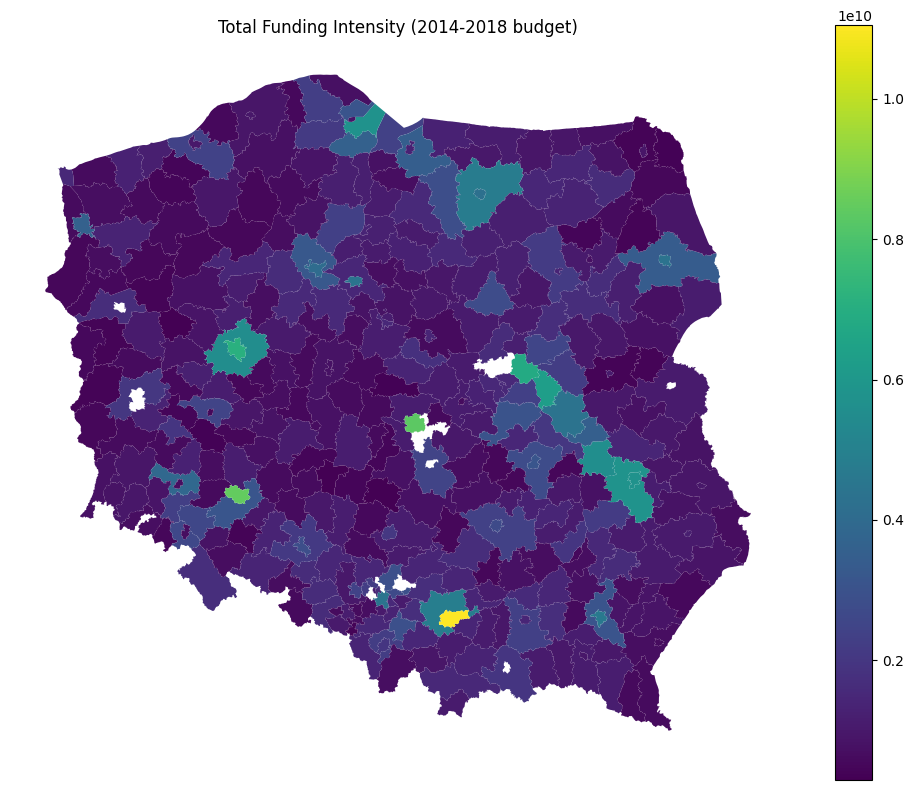

In [ ]:
import matplotlib.pyplot as plt

# Aggregate total funding per gmina (sum over all years)
agg_total = df_final_powiat_panel.groupby('powiat_id')['EU_subsidy_PLN'].sum().reset_index()

# 2. Merge with geometries
agg_total['powiat_id'] = agg_total['powiat_id'].astype(str).str.zfill(7)
powiaty_geoms['JPT_KOD_JE'] = powiaty_geoms['JPT_KOD_JE'].astype(str).str.zfill(7)
merged = agg_total.merge(powiaty_geoms, left_on='powiat_id', right_on='JPT_KOD_JE')
gdf = gpd.GeoDataFrame(merged, geometry='geometry')

# 3. Plot the total funding intensity map
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(
    column='EU_subsidy_PLN',
    ax=ax,
    cmap='viridis',
    legend=True,
    missing_kwds={"color": "lightgrey"}
)
ax.set_title('Total Funding Intensity (2014-2020 budget)')
ax.axis('off')
plt.tight_layout()
plt.show()

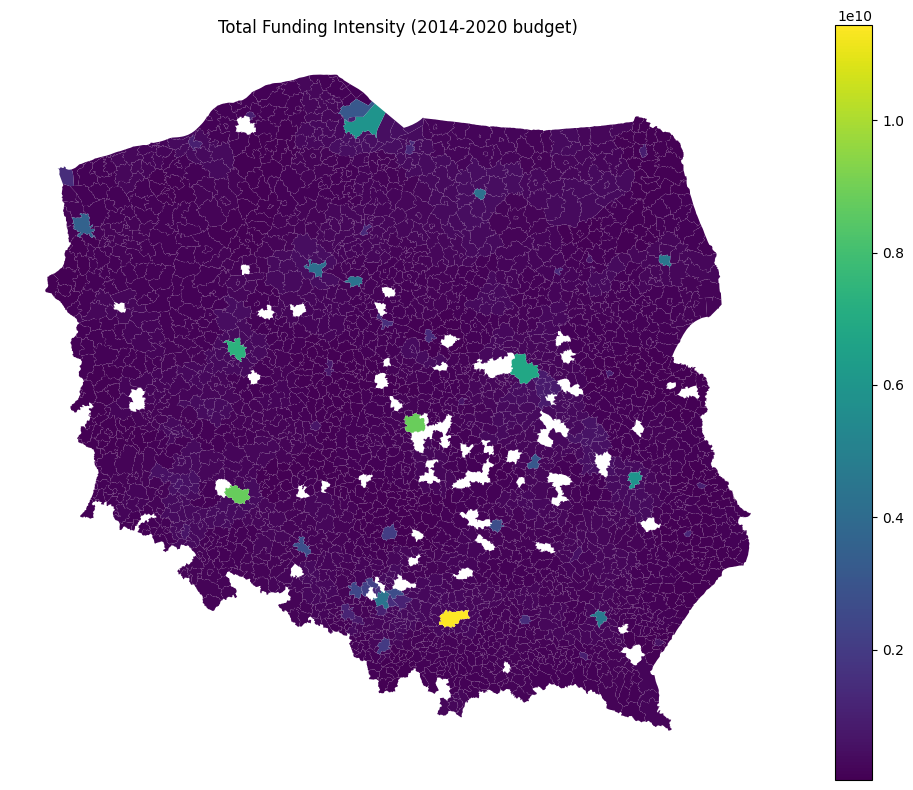

In [20]:
import matplotlib.pyplot as plt

# 1. Aggregate total funding per gmina (sum over all years)
agg_total = df_disaggregated.groupby('gmina_id')['EU_subsidy_PLN'].sum().reset_index()

# 2. Merge with geometries
agg_total['gmina_id'] = agg_total['gmina_id'].astype(str).str.zfill(7)
gminy_geoms['JPT_KOD_JE'] = gminy_geoms['JPT_KOD_JE'].astype(str).str.zfill(7)
merged = agg_total.merge(gminy_geoms, left_on='gmina_id', right_on='JPT_KOD_JE')
gdf = gpd.GeoDataFrame(merged, geometry='geometry')

# 3. Plot the total funding intensity map
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(
    column='EU_subsidy_PLN',
    ax=ax,
    cmap='viridis',
    legend=True,
    missing_kwds={"color": "lightgrey"}
)
ax.set_title('Total Funding Intensity (2014-2020 budget)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [22]:
df_disaggregated.to_csv(r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo\data\clean\treatment\eu_flows\final\gmina_level_201420.csv", index = False)

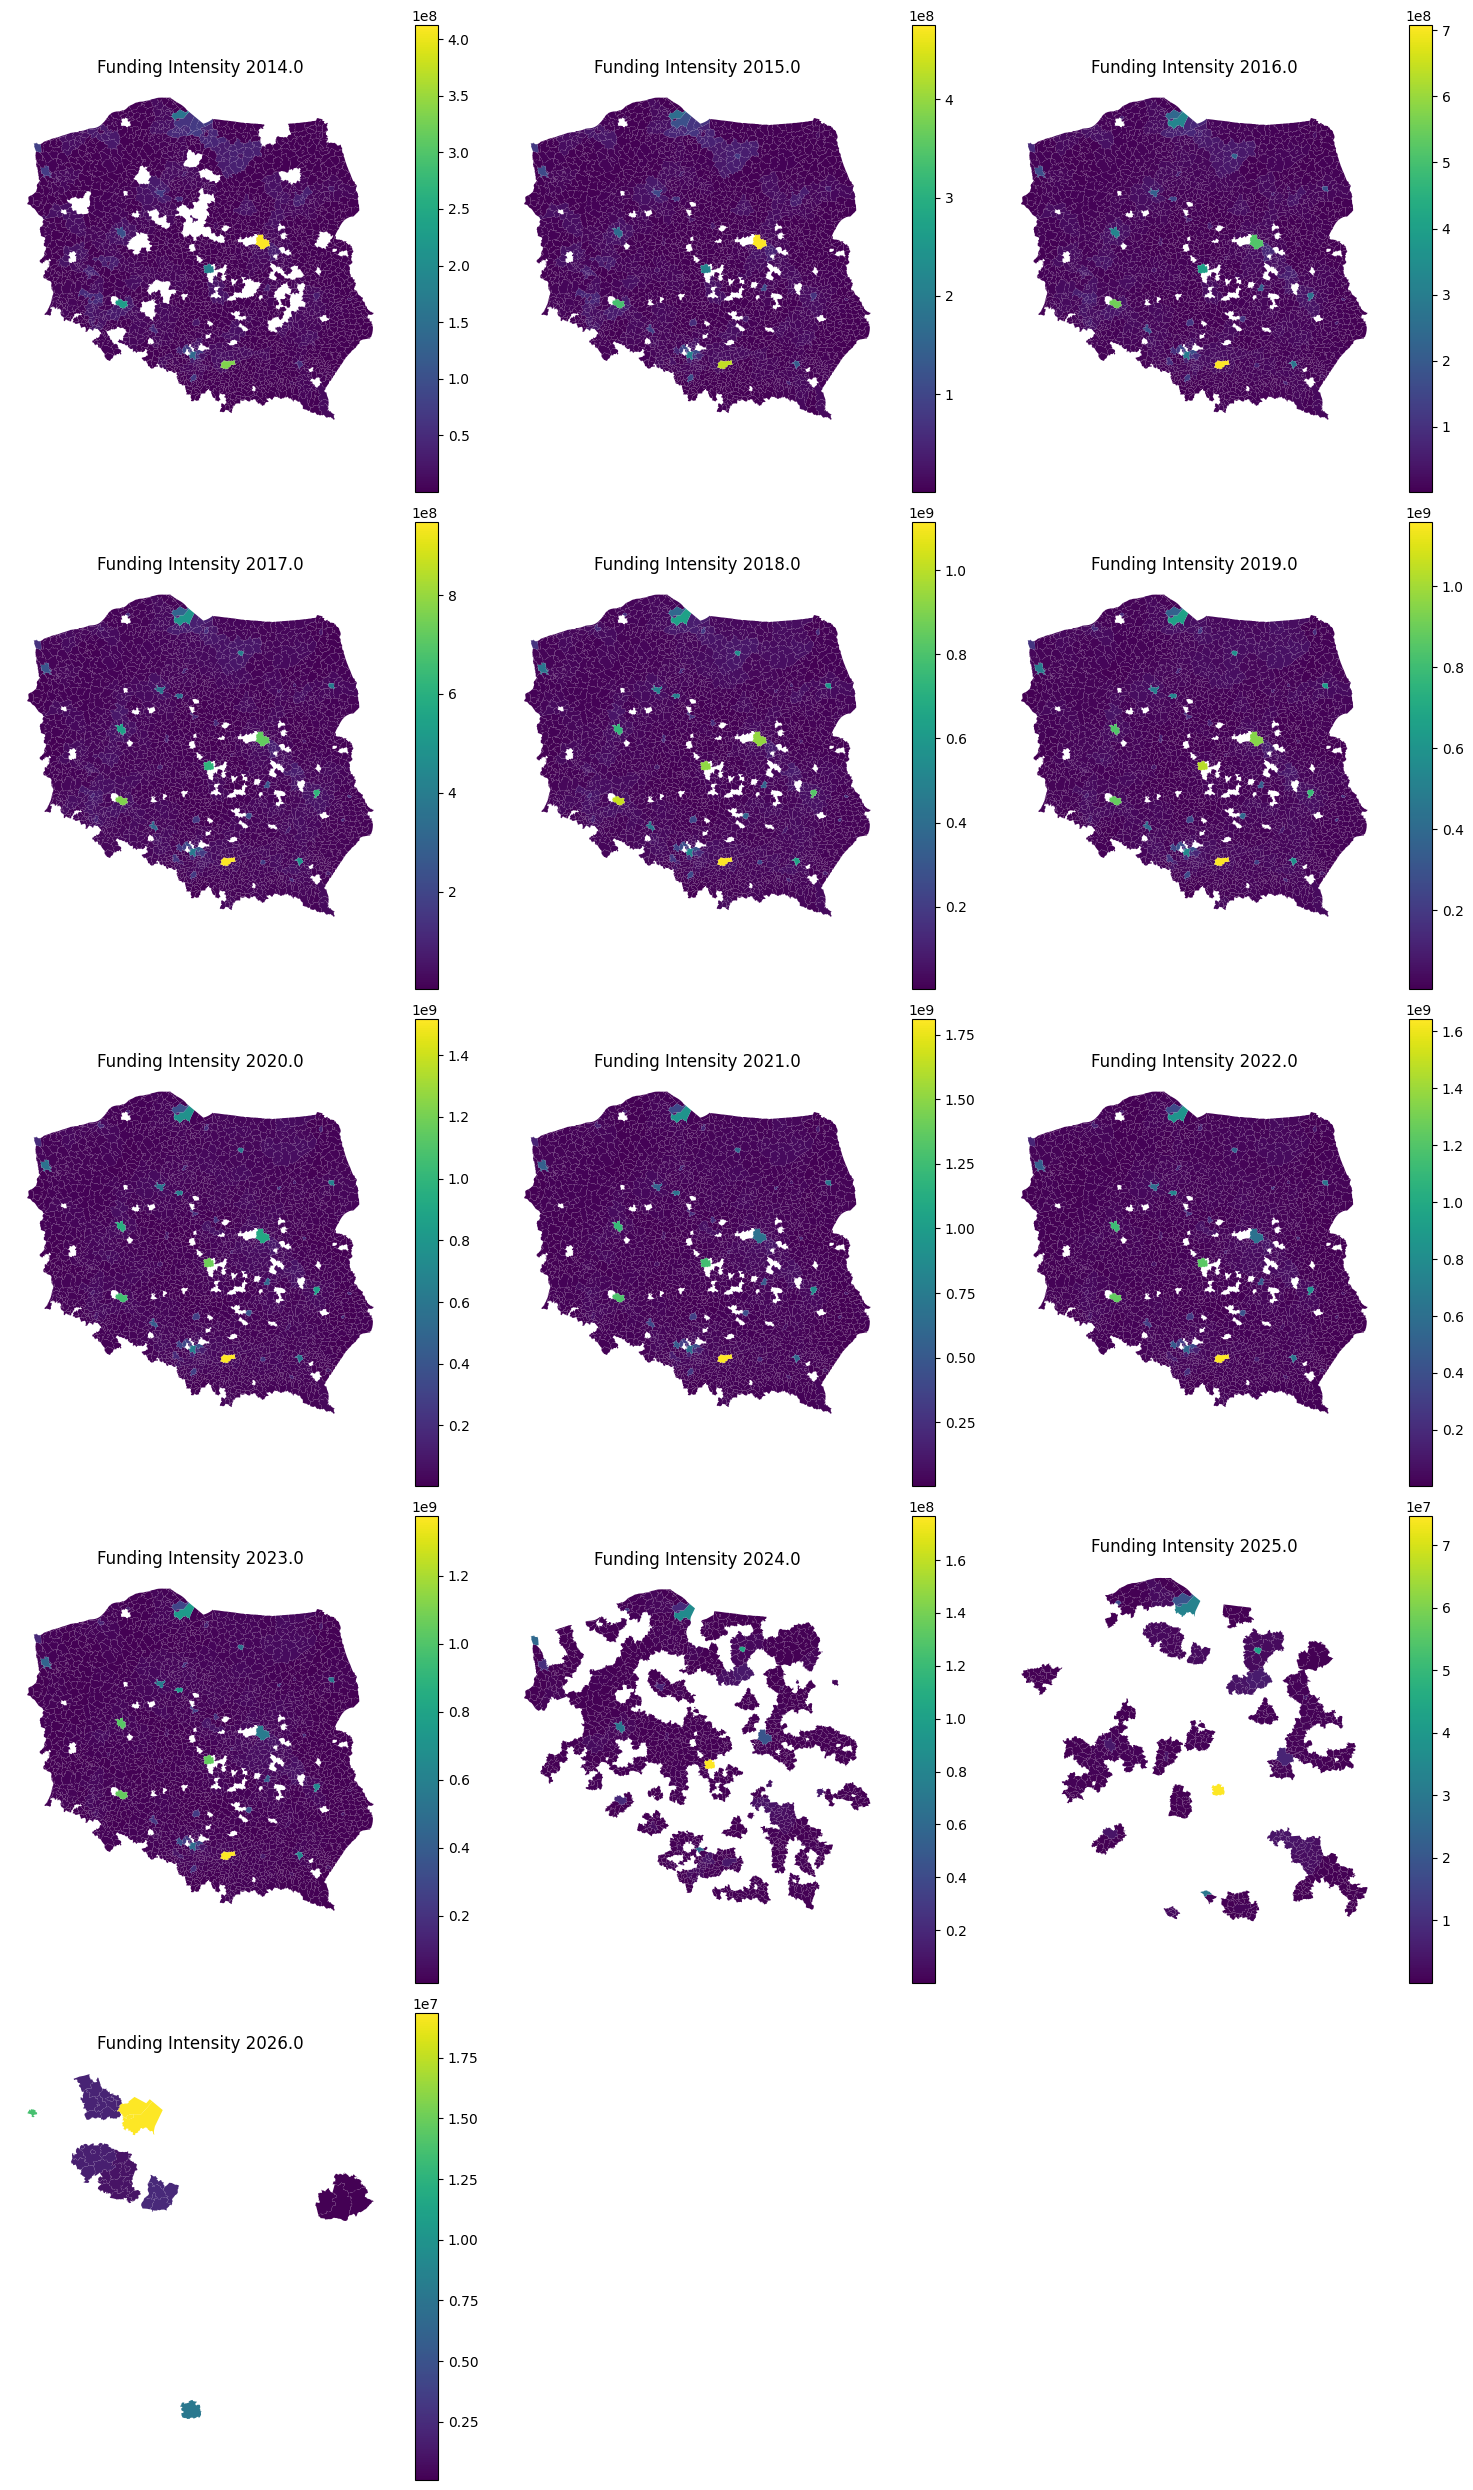

In [23]:
# Assuming final_panel has columns: 'gmina_id', 'year', 'EU_subsidy_PLN'
agg = df_disaggregated.groupby(['gmina_id', 'Year'])['EU_subsidy_PLN'].sum().reset_index()

# 2. Merge with geometries
agg['gmina_id'] = agg['gmina_id'].astype(str).str.zfill(7)
gminy_geoms['JPT_KOD_JE'] = gminy_geoms['JPT_KOD_JE'].astype(str).str.zfill(7)
merged = agg.merge(gminy_geoms, left_on='gmina_id', right_on='JPT_KOD_JE')
gdf = gpd.GeoDataFrame(merged, geometry='geometry')

# 3. Plot for selected years (adjust years as needed)
years = sorted(gdf['Year'].unique())
n_years = len(years)
ncols = 3
nrows = (n_years + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    gdf[gdf['Year'] == year].plot(
        column='EU_subsidy_PLN',
        ax=ax,
        cmap='viridis',
        legend=True,
        missing_kwds={"color": "lightgrey"}
    )
    ax.set_title(f'Funding Intensity {year}')
    ax.axis('off')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()